In [11]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="6" color="red">ch12. 데이터 시각화</font>

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화한 그래프를 저장할 해상도 높이기
%config InlineBackend.figure_format = 'retina'

# 한글설정(Win/MacOS)
plt.rc('font', family='Malgun Gothic') #윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='ignore') # 경고 메세지 안 보이게
# warnings.filterwarnings(action='default') # 기본 경고 메세지 다 보이게

# Seaborn
- matplotlib기반으로 만든 고수준 그래픽 라이브러리
    * 공식 API 사이트 : https://seaborn.pydata.org/api.html
- Seaborn으로 그래프를 그리기 위해서 다음의 단계를 따른다
    1) 데이터 준비
    2) 미적 속성 설정
    3) 함수를 이용해서 그래프 그리기(관계형-수치형, 범주형, 쌍관계, 밀도, 회귀, 다중그래프 ...)
        - 그래프 커스텀마이징
    4) 그래프 출력(show), 저장(savefig)

## 데이터 준비하기
- iris, titanic

In [12]:
iris = sns.load_dataset('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [13]:
titanic = sns.load_dataset('titanic')
# Survived : 생존 여부 (0 = 사망, 1 = 생존)
# Pclass : 티켓 클래스 (1 = 1등석, 2 = 2등석, 3 = 3등석)
# Sex : 성별
# Age : 나이
# SibSp : 함께 탑승한 자녀 / 배우자 의 수
# Parch : 함께 탑승한 부모님 / 아이들 의 수
# Ticket : 티켓 번호
# Fare : 탑승 요금
# Cabin : 수하물 번호
# Boat : 탈출한 보트가 있다면 boat 번호
# Embarked : 탑승 선착장 (C = Cherbourg, Q = Queenstown, S = Southampton)
titanic.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [9]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## 미적 속성 설정(style, context, palette, figsize...)
### 그래프 스타일 지정
- 미적 속성 설정후, 한글 설정을 재실행
    - plt.rc('font', family='Malgun Gothic') #윈도우즈
    - plt.rc('axes', unicode_minus=False)
    - 범례(교안20p) : https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot

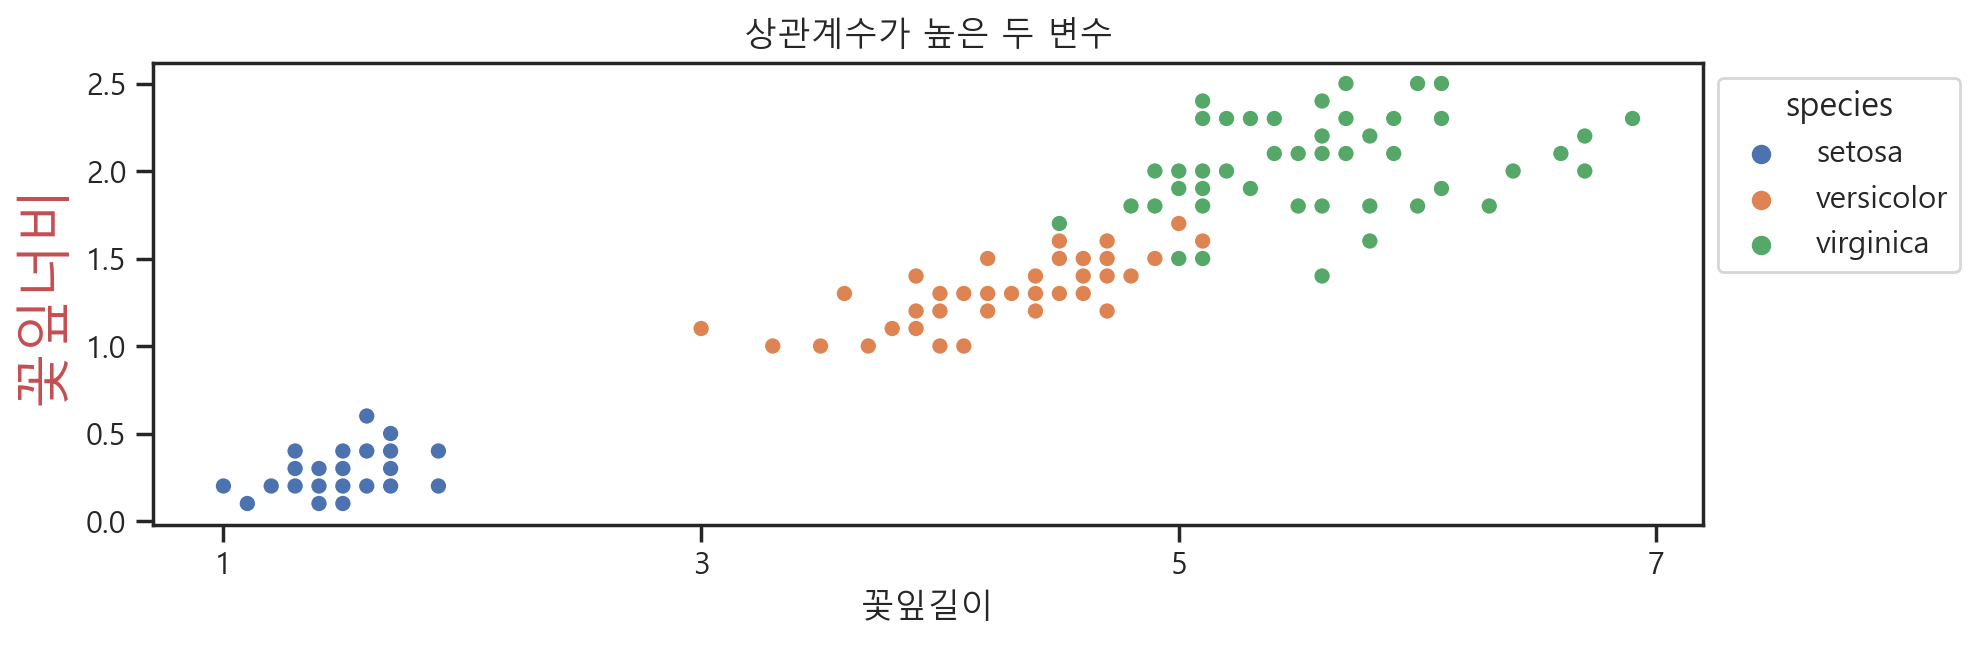

In [14]:
plt.rcParams['figure.figsize'] = (10,3)
sns.set(style='ticks') # darkgrid, whitegrid, dark, white, ticks
# sns.set_style('whitegrid')
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

ax = sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species')
# plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set(title='상관계수가 높은 두 변수',
      xlabel='꽃잎길이',
      xticks=[1, 3, 5, 7])
ax.set_ylabel('꽃잎너비', fontsize=20, color='r')
plt.show()

### 컨텍스트 지정(배율)

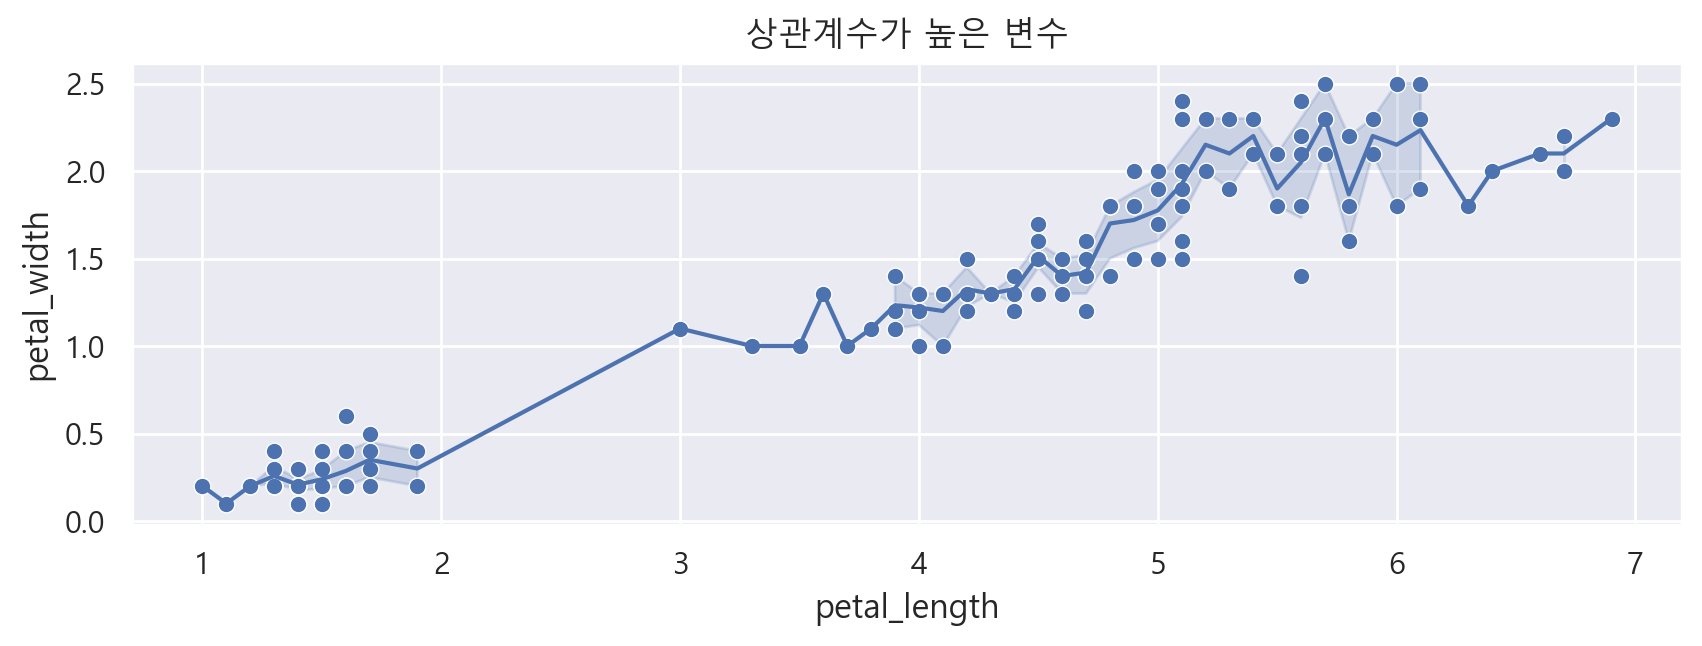

In [15]:
sns.set(context='notebook') # 기본값notebook(1.0), paper(0.8), talk(1.3), poster(1.8)
# sns.set_context('notebook')
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
sns.lineplot(data=iris, x='petal_length', y='petal_width')
sns.scatterplot(data=iris, x='petal_length', y='petal_width')
plt.title('상관계수가 높은 변수')
plt.show()

### 컬러 팔레트
- https://seaborn.pydata.org/generated/seaborn.color_palette.html#seaborn.color_palette (교안 54p)
- https://matplotlib.org/stable/users/explain/colors/colormaps.html
- https://seaborn.pydata.org/tutorial/color_palettes.html

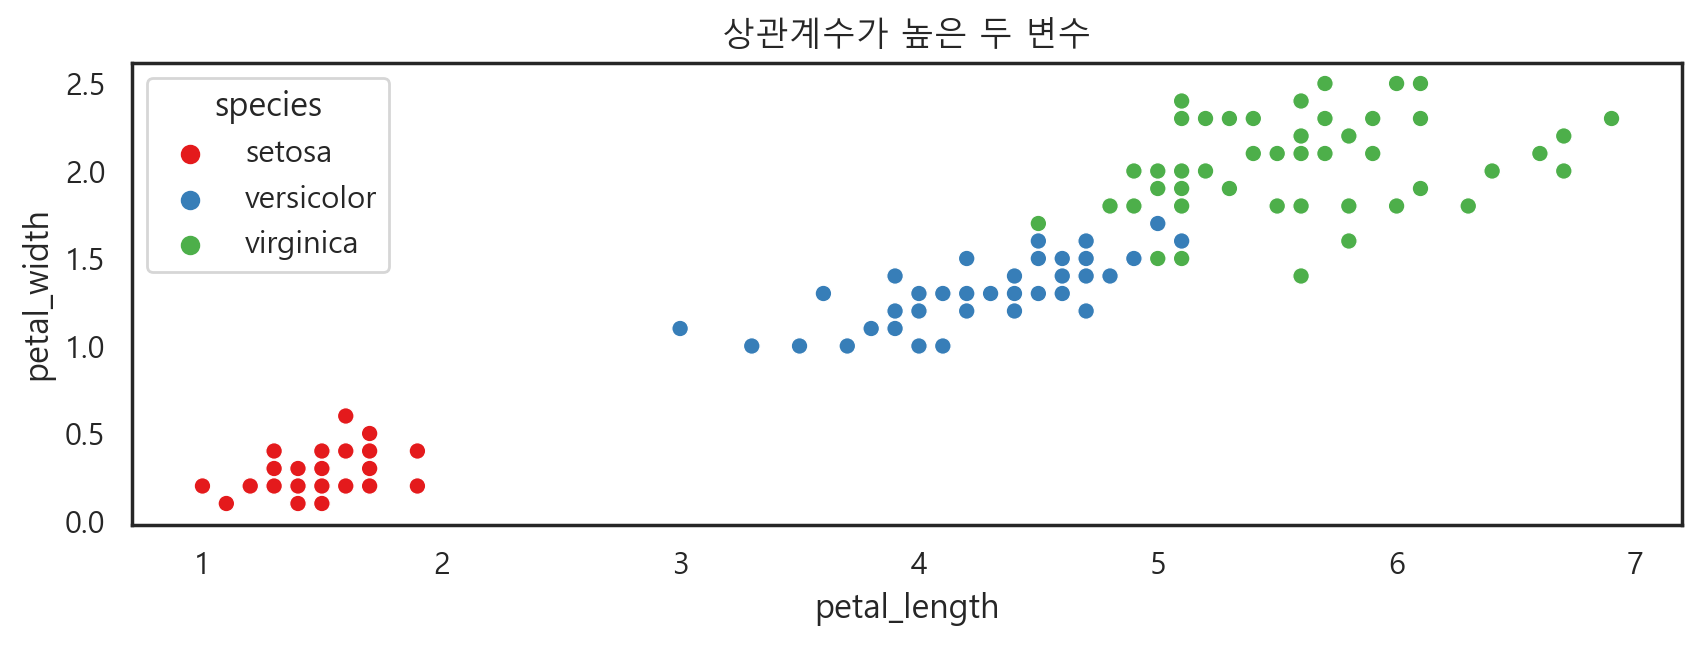

In [16]:
sns.set(palette='Pastel1', style='white', context='notebook') # 기본 미적 속성 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
ax = sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species', palette='Set1')
ax.set(title='상관계수가 높은 두 변수')
plt.show()

In [17]:
# 시각화한 그래프를 저장할 해상도 높이기
%config InlineBackend.figure_format = 'retina'
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
# 미적 속성 셋팅
sns.set(style='white',
       context='notebook',
       palette='Dark2',
       rc={'figure.figsize': (12,3)})
# 한글 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='ignore') # 경고 메세지 안 보이게
# warnings.filterwarnings(action='default') # 기본 경고 메세지 다 보이게

In [18]:
iris = sns.load_dataset('iris')
titanic = sns.load_dataset('titanic')

# Seaborn 함수로 그래프 그리기
### 관계형 그래프
- scatterplot, lineplot, relplot(서브플롯 제공)

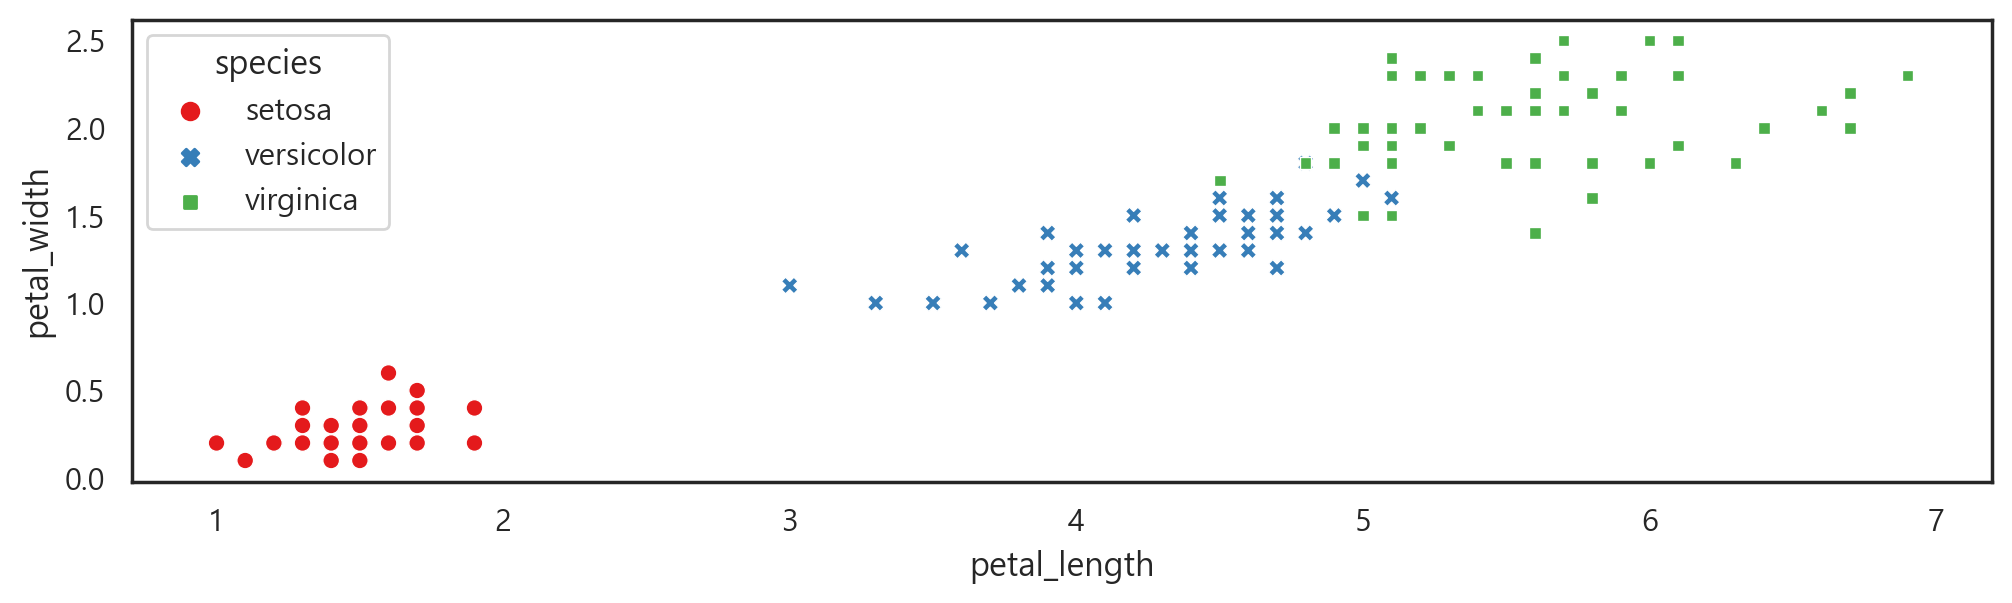

In [21]:
# 종별 다른 색상과 다른 스타일의 scatterplt
sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species', palette='Set1',
               style='species')
# sns.scatterplot(x=iris.petal_length, y=iris.petal_width, hue=iris.species, palette='Set1',
#                style=iris.species)
plt.show()

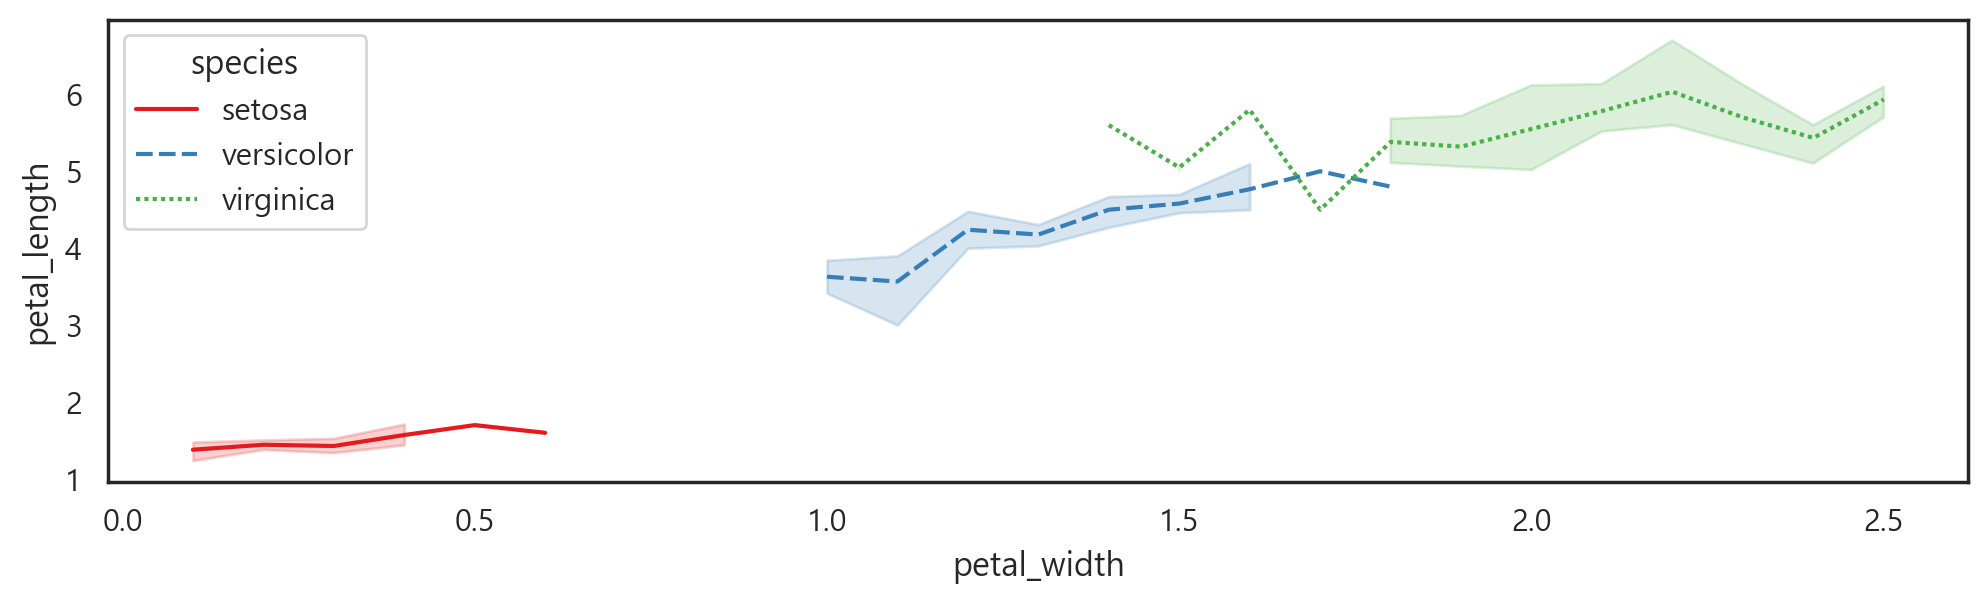

In [22]:
# 종별 다른 색상과 다른 스타일의 lineplot
sns.lineplot(data=iris, x='petal_width', y='petal_length', hue='species', 
             style='species', palette='Set1')
plt.show()

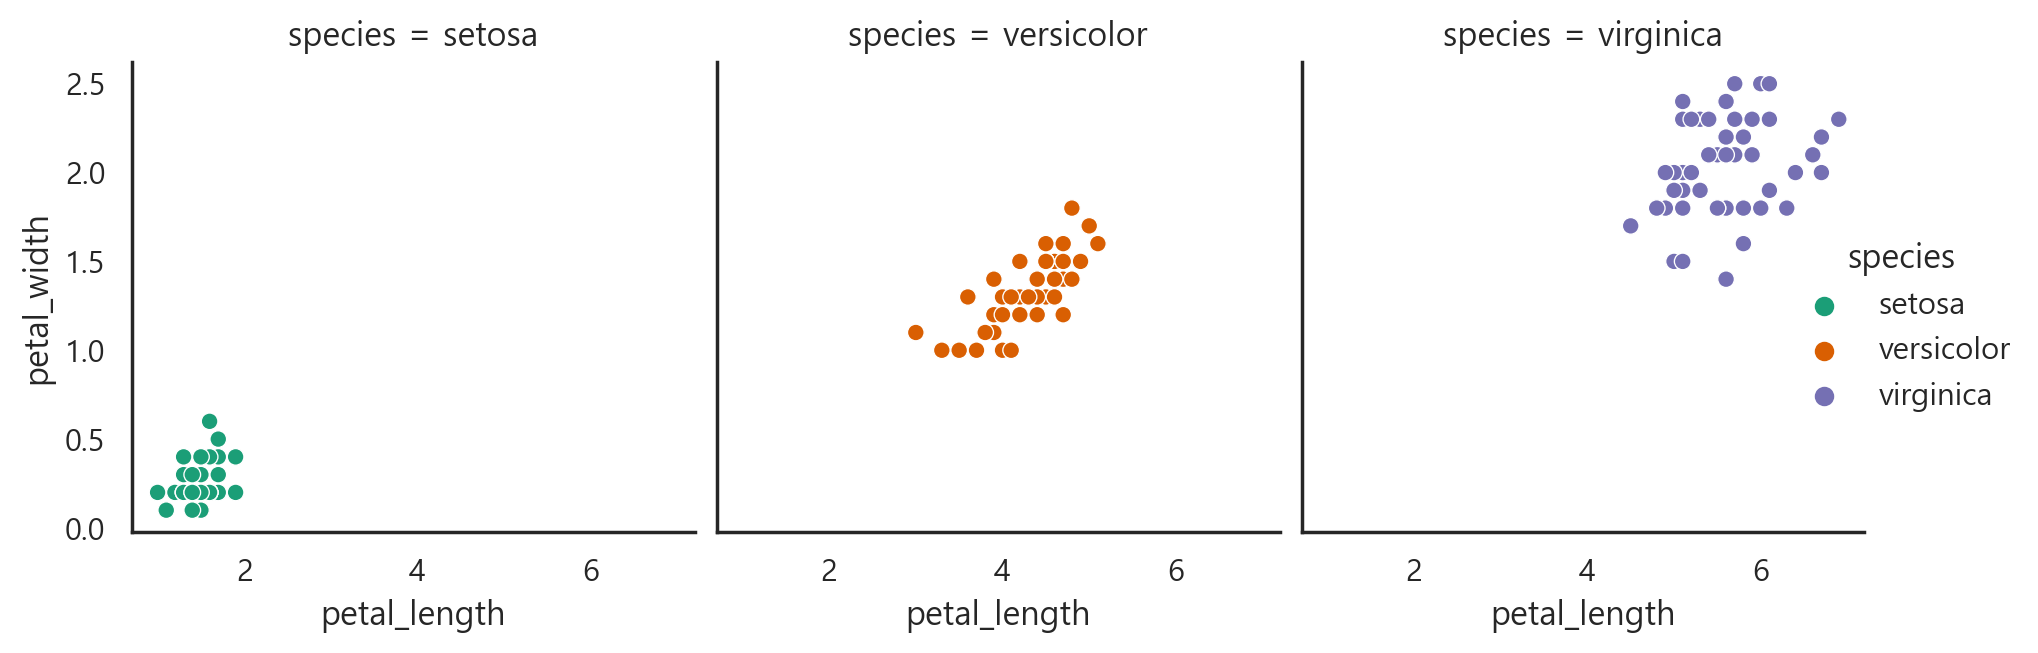

In [23]:
# 종별 scatterplot을 서브플롯으로 => relplot(관계형 그래프에서 서브플롯을 그리는 함수)
g = sns.relplot(data=iris, x='petal_length', y='petal_width', hue='species',
           # 기본값은 kind='scatter',
           col='species', # col 단위로 서브플롯 표현
           # col_wrap=2,    # 한줄에 표현될 서브플롯 수 
           # facet_kws={'sharey':False, 'sharex':False}  # 축공유 여부
           )
g.fig.set_size_inches(10,3)
plt.show()

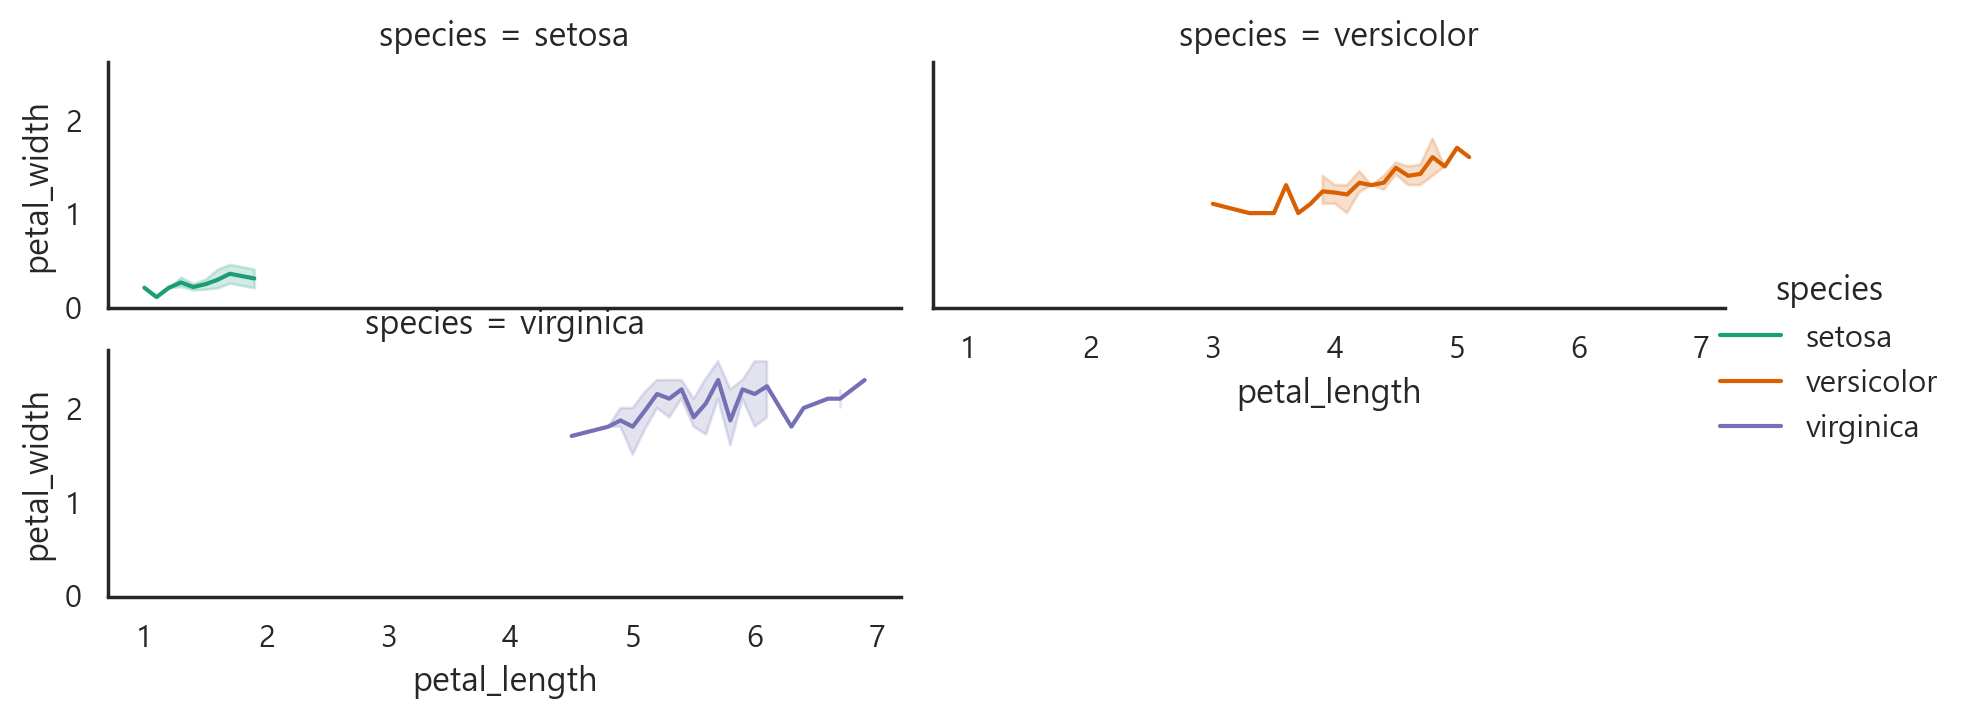

In [24]:
# 종별 lineplot을 서브플롯으로 => relplot(관계형 그래프에서 서브플롯을 그리는 함수)
g = sns.relplot(data=iris, 
                x='petal_length', 
                y='petal_width', 
                hue='species',
                kind='line',
                col='species', # col 단위로 서브플롯 표현
                col_wrap=2,    # 한줄에 표현될 서브플롯 수 
               # facet_kws={'sharey':False, 'sharex':False}  # 축공유 여부
           )
g.fig.set_size_inches(10,3)
plt.show()

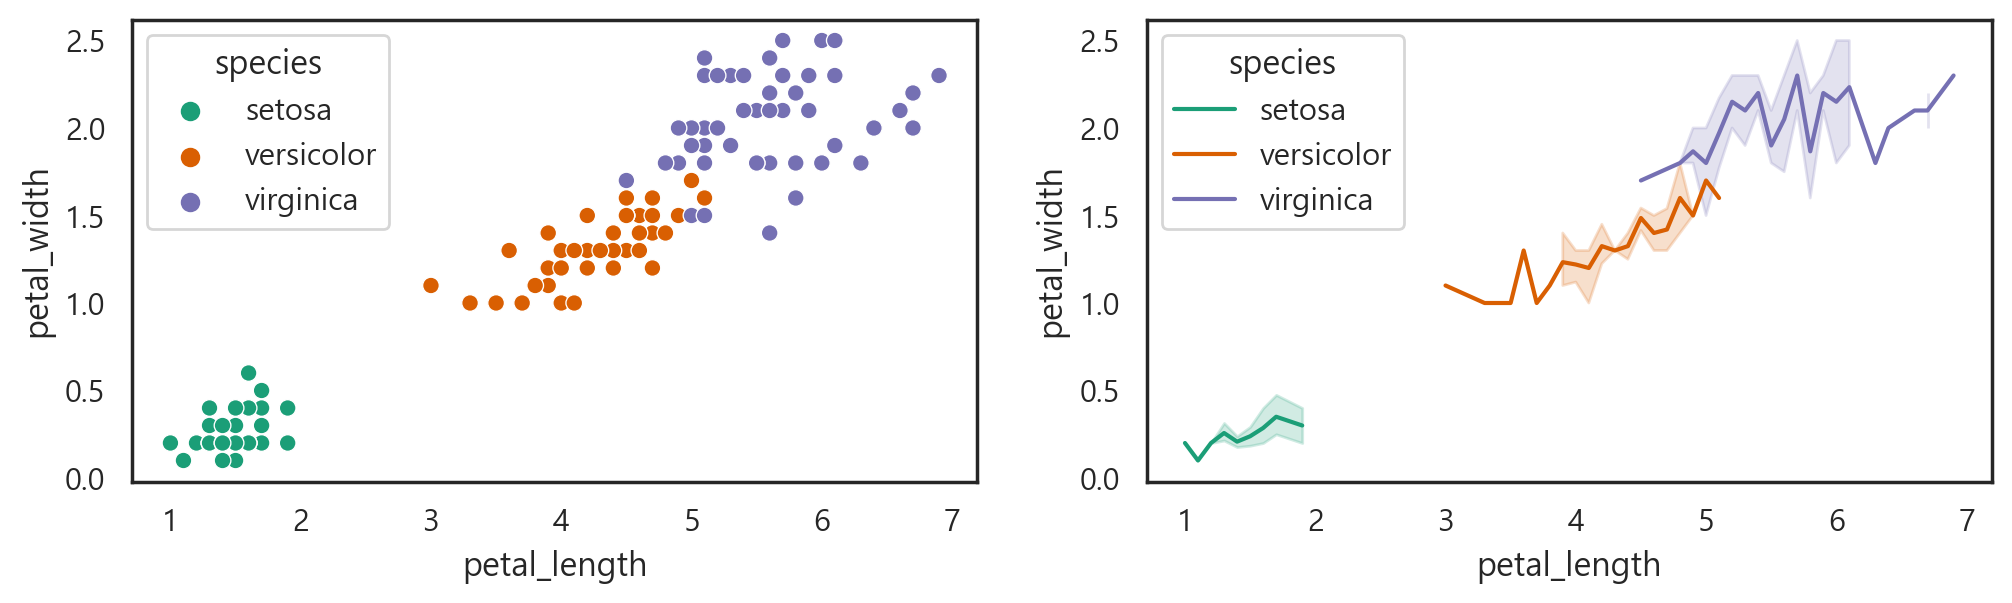

In [25]:
# 서브플롯 : scaterplot, lineplot
fig, ax = plt.subplots(1, 2)
sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species', ax=ax[0])
sns.lineplot(data=iris, x='petal_length', y='petal_width', hue='species', ax=ax[1])
plt.show()